In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize
from utils import *

In [50]:
EJ = 2.5
EC = 0.06
EL = 0.13

qubit_level = 40

def get_shift(ele,Delta_ij):
    return abs(ele)**2 / Delta_ij

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]
    shifts_from_zero = [get_shift(elements[0,ql2],evals[ql2]-evals[0]-Er) for ql2 in range(qubit_level)] 
    shift_from_zero = sum(shifts_from_zero)
    shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)

    return abs(shift_from_one-shift_from_zero)

initial_guess = [2.33]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.457136000663887e-05
             x: [ 2.338e+00]
           nit: 19
          nfev: 39
 final_simplex: (array([[ 2.338e+00],
                       [ 2.338e+00]]), array([ 5.457e-05,  1.156e-04]))
Optimal solution: [2.33840295]
Objective value: 5.457136000663887e-05


qbt freq at osc 1:	2.27350, 	diff to at osc ground -0.01087, 0.4759% diff
qbt freq at osc 2:	2.26565, 	diff to at osc ground -0.01872, 0.8195% diff
qbt freq at osc 3:	2.25973, 	diff to at osc ground -0.02464, 1.0787% diff
qbt freq at osc 4:	2.25519, 	diff to at osc ground -0.02918, 1.2774% diff
qbt freq at osc 5:	2.25170, 	diff to at osc ground -0.03267, 1.4303% diff
qbt freq at osc 6:	2.24902, 	diff to at osc ground -0.03534, 1.5472% diff
qbt freq at osc 7:	2.24701, 	diff to at osc ground -0.03736, 1.6355% diff
qbt freq at osc 8:	2.24553, 	diff to at osc ground -0.03884, 1.7004% diff
qbt freq at osc 9:	2.24448, 	diff to at osc ground -0.03989, 1.7461% diff
qbt freq at osc 10:	2.24380, 	diff to at osc ground -0.04057, 1.7761% diff
qbt freq at osc 11:	2.24341, 	diff to at osc ground -0.04096, 1.7929% diff
qbt freq at osc 12:	2.24328, 	diff to at osc ground -0.04109, 1.7986% diff
qbt freq at osc 13:	2.24336, 	diff to at osc ground -0.04100, 1.7950% diff
qbt freq at osc 14:	2.24363, 	diff

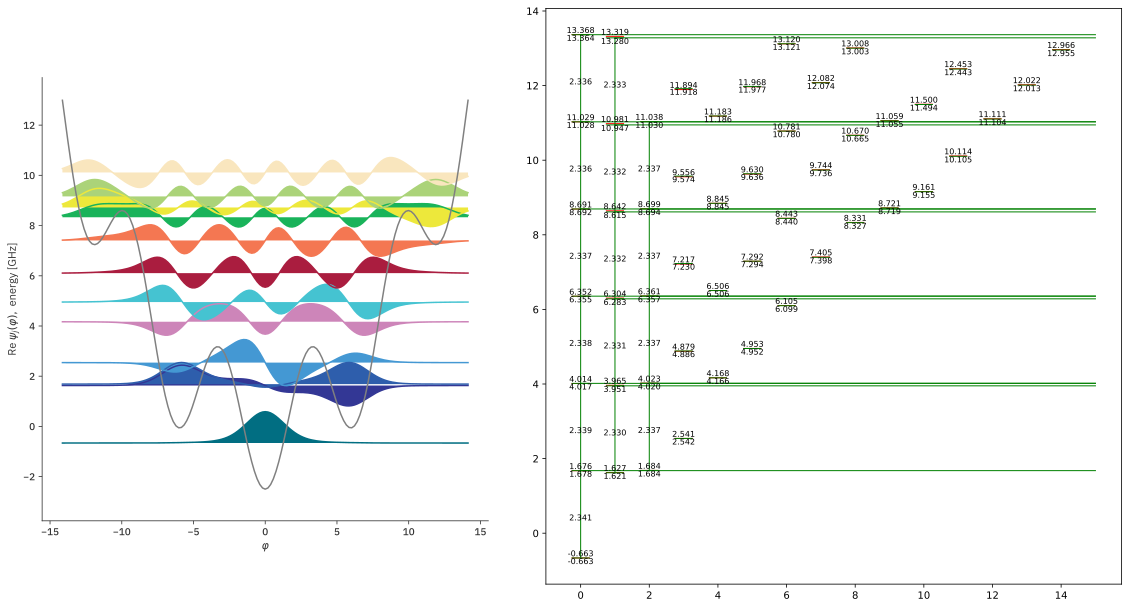

In [55]:
EJ = 2.5
EC = 0.8
EL = 0.13
Er = 3.5
# g = abs(3.661490120722615 - Er)

# g = 0.4
# print(g)

# g = abs(evals[7]-evals[0]-result.x[0])
g = 0.1
# print(f"g:{g}")


max_ol = 30
max_ql = 30
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    # Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ]
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    ground_freq = dressed_ener(1,0)-dressed_ener(0,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(1,i)-dressed_ener(0,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 2nd state compared to 20-21 (non-linearity): {(dressed_ener(2,i+1)-dressed_ener(2,i))  -(dressed_ener(2,1)-dressed_ener(2,0))}")

    print(f"")
    print(f"00-01: {(dressed_ener(0,1)-dressed_ener(0,0)):.4f}, diff to 20-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 20-01: {abs((dressed_ener(1,1)-dressed_ener(1,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

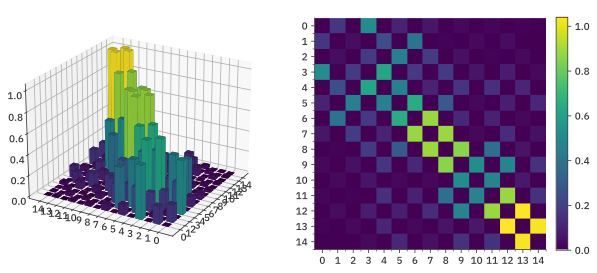

In [54]:
system.qbt.plot_matrixelements(operator = 'n_operator',evals_count = 15)